
mean value:  4680.00
mode value: There is No Mode
median value:  3750.00

Q1: 3525.0
Q3: 4375.0
IQR: 850.0
LowerBound: 2250.0
UpperBound: 5650.0
Outliers: [12000]
The variance value:  6890666.67
The Standard Deviaton value:  2625.01

The Coefficient of variation value:  56.09

 Skewness value:  2.94


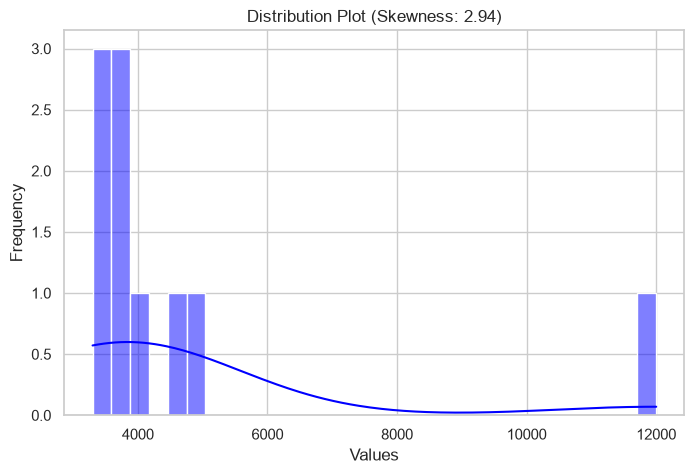

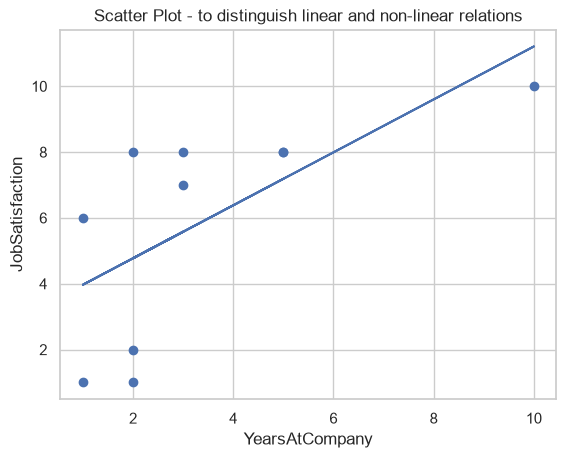

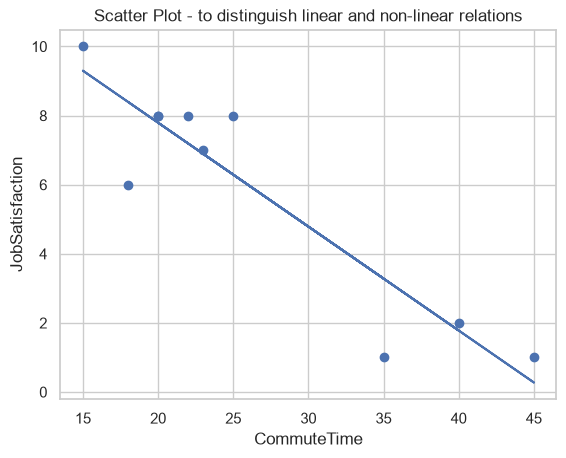

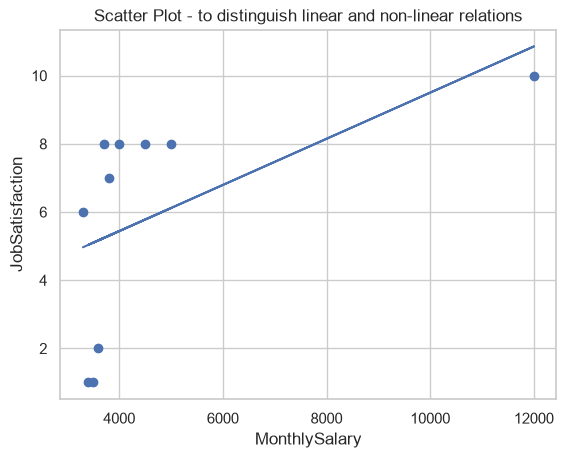

Pearson’s Correlation Coefficients:
between job satisfaction and years at company is 0.66 and they have Positive correlation
between job satisfaction and Monthly Salary is 0.54 and they have Positive correlation
between job satisfaction and commute time is -0.92 and they have Negative correlation
     
Spearman’s Rank Correlation Coefficients:
between job satisfaction and years at company is 0.80 and they have Positive correlation
between job satisfaction and Monthly Salary is 0.86 and they have Positive correlation
between job satisfaction and commute time is -0.73 and they have Negative correlation
     


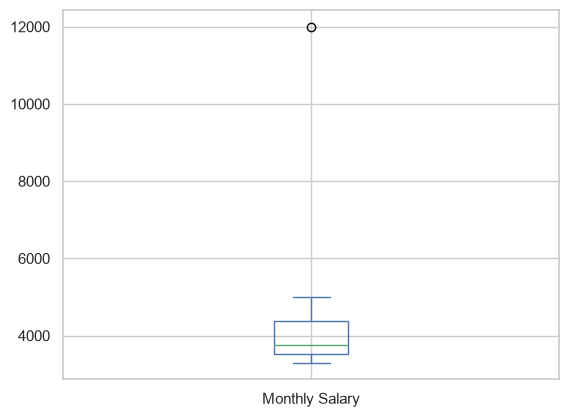

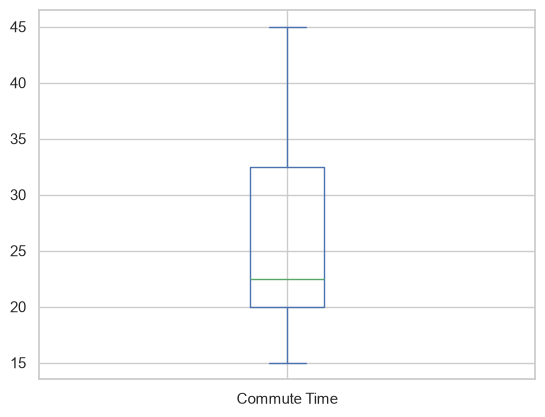

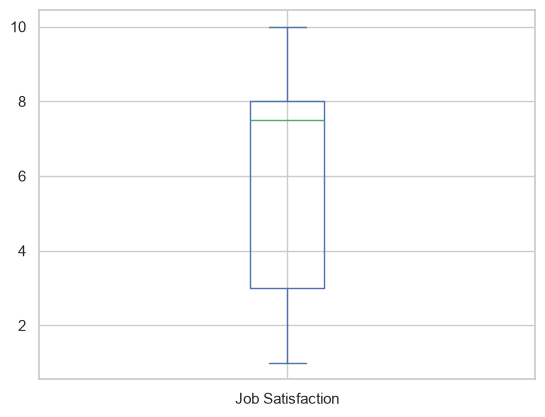

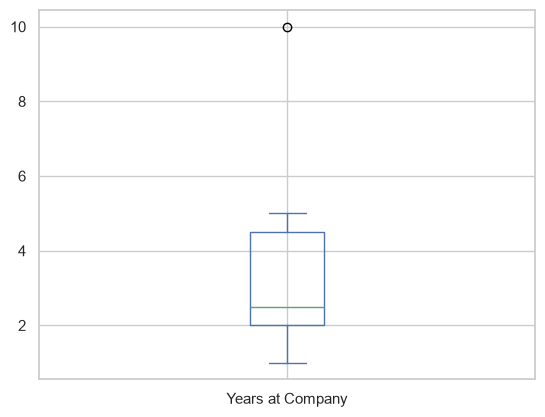

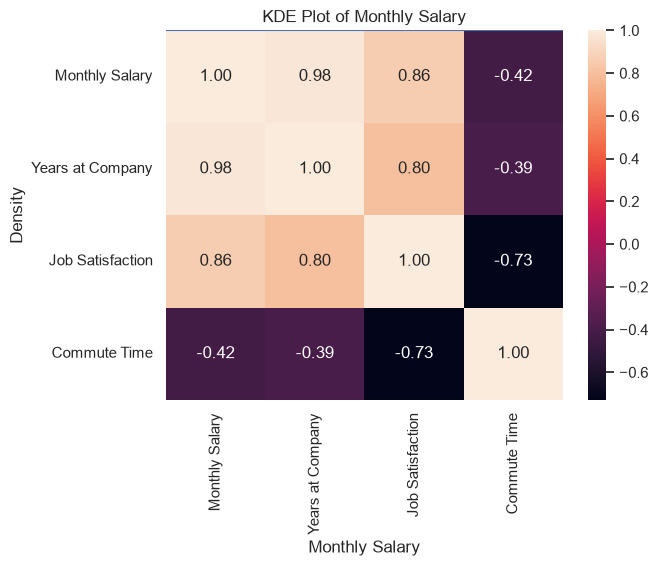

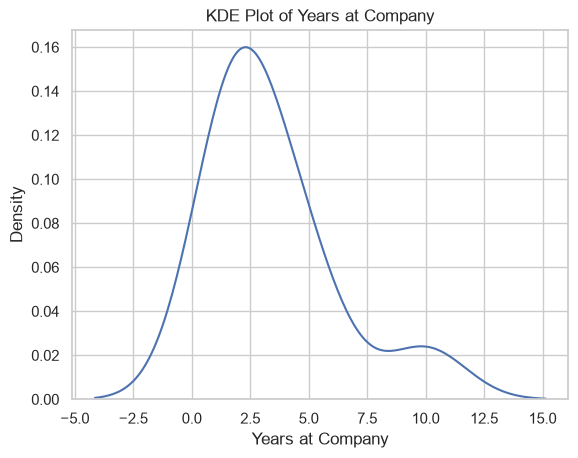

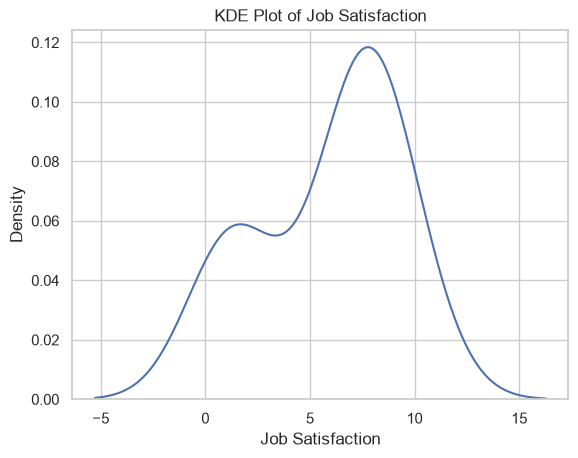

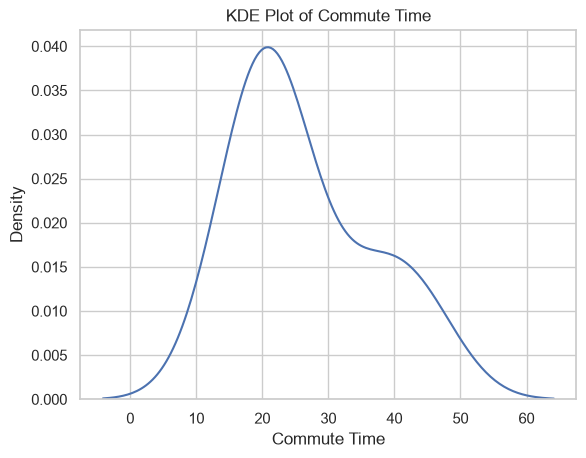

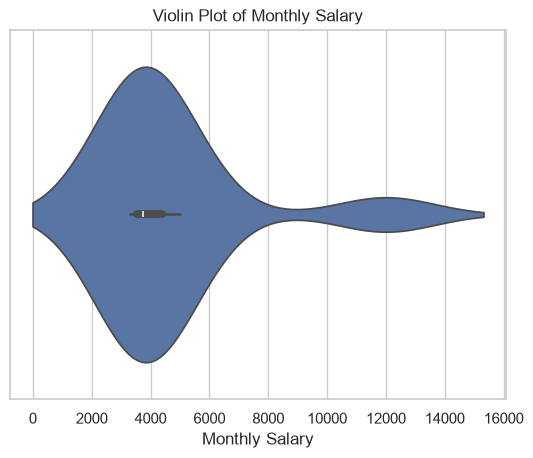

In [1]:
import pandas as pd

f = pd.read_excel('employee_data.xlsx')
MonthlySalary = f['Monthly Salary']
# Calculation of the mean, median, and mode for the Monthly Salary
Mean_MonthlySalary = MonthlySalary.mean()
Mode_MonthlySalary = MonthlySalary.mode()
if len(Mode_MonthlySalary) > 1:
    Mode_MonthlySalary = 'There is No Mode'
Median_MonthlySalary = MonthlySalary.median()

print(f"""
mean value: {Mean_MonthlySalary: .2f}
mode value: {Mode_MonthlySalary}
median value: {Median_MonthlySalary: .2f}
""")
# Calculation of the upper and lower bounds using the Interquartile Range (IQR) and identifying any outliers for the Monthly Salary
Q1 = MonthlySalary.quantile(0.25)
Q3 = MonthlySalary.quantile(0.75)
IQR = Q3 - Q1
LowerBound = Q1 - 1.5 * IQR
UpperBound = Q3 + 1.5 * IQR
Outliers = MonthlySalary[(MonthlySalary < LowerBound) | (MonthlySalary > UpperBound)].tolist()
print (f"""Q1: {Q1}
Q3: {Q3}
IQR: {IQR}
LowerBound: {LowerBound}
UpperBound: {UpperBound}
Outliers: {Outliers}""")

# calculation of Variance and Standard deviation for the Monthly Salary
Variance_MonthlySalary = MonthlySalary.var()
StandardDeviation_MonthlySalary = MonthlySalary.std()
print(f"""The variance value: {Variance_MonthlySalary: .2f}
The Standard Deviaton value: {StandardDeviation_MonthlySalary: .2f}
""")
# calculation of Coefficient of variation
CV_MonthlySalary = (StandardDeviation_MonthlySalary / Mean_MonthlySalary) * 100
print(f"""The Coefficient of variation value: {CV_MonthlySalary : .2f}
""")

# calculation of skewness for the Monthly Salary
Skew_MonthlySalary = MonthlySalary.skew()
print(f""" Skewness value: {Skew_MonthlySalary: .2f}""")

# drawing Skewness plot
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.histplot(MonthlySalary, kde=True, color='blue', bins=30)
plt.title(f'Distribution Plot (Skewness: {Skew_MonthlySalary:.2f})')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()

#Drawing Scatter Plot to see if the relations are linear or non-linear 
import numpy as np
YearsAtCompany = f['Years at Company']
JobSatisfaction = f['Job Satisfaction']
CommuteTime = f['Commute Time']
plt.scatter(YearsAtCompany, JobSatisfaction)
m, b = np.polyfit(YearsAtCompany, JobSatisfaction, 1)
plt.title(f'Scatter Plot - to distinguish linear and non-linear relations')
plt.plot(YearsAtCompany, m*YearsAtCompany + b)
plt.xlabel('YearsAtCompany')
plt.ylabel('JobSatisfaction')
plt.show()

plt.scatter(CommuteTime, JobSatisfaction)
m, b = np.polyfit(CommuteTime, JobSatisfaction, 1)
plt.title(f'Scatter Plot - to distinguish linear and non-linear relations')
plt.plot(CommuteTime, m*CommuteTime + b)
plt.xlabel('CommuteTime')
plt.ylabel('JobSatisfaction')
plt.show()

plt.scatter(MonthlySalary, JobSatisfaction)
m, b = np.polyfit(MonthlySalary, JobSatisfaction, 1)
plt.title(f'Scatter Plot - to distinguish linear and non-linear relations')
plt.plot(MonthlySalary, m*MonthlySalary + b)
plt.xlabel('MonthlySalary')
plt.ylabel('JobSatisfaction')
plt.show()

# Pearson’s Correlation Coefficient:
correlation_value_J_M = JobSatisfaction.corr(MonthlySalary)
if correlation_value_J_M > 0:
    result1 = "Positive correlation"
else:
    result1 = "Negative correlation"
correlation_value_J_Y = JobSatisfaction.corr(YearsAtCompany)
if correlation_value_J_Y > 0:
    result2 = "Positive correlation"
else:
    result2 = "Negative correlation"
correlation_value_J_C = JobSatisfaction.corr(CommuteTime)
if correlation_value_J_C > 0:
    result3 = "Positive correlation"
else:
    result3 = "Negative correlation"
print(f"""Pearson’s Correlation Coefficients:
between job satisfaction and years at company is {correlation_value_J_Y:.2f} and they have {result1}
between job satisfaction and Monthly Salary is {correlation_value_J_M:.2f} and they have {result2}
between job satisfaction and commute time is {correlation_value_J_C:.2f} and they have {result3}
     """)

# Spearman’s Rank Correlation Coefficient:
correlation_value_J_M = JobSatisfaction.corr(MonthlySalary , method='spearman')
if correlation_value_J_M > 0:
    result1 = "Positive correlation"
else:
    result1 = "Negative correlation"
correlation_value_J_Y = JobSatisfaction.corr(YearsAtCompany , method='spearman')
if correlation_value_J_Y > 0:
    result2 = "Positive correlation"
else:
    result2 = "Negative correlation"
correlation_value_J_C = JobSatisfaction.corr(CommuteTime , method='spearman')
if correlation_value_J_C > 0:
    result3 = "Positive correlation"
else:
    result3 = "Negative correlation"
print(f"""Spearman’s Rank Correlation Coefficients:
between job satisfaction and years at company is {correlation_value_J_Y:.2f} and they have {result1}
between job satisfaction and Monthly Salary is {correlation_value_J_M:.2f} and they have {result2}
between job satisfaction and commute time is {correlation_value_J_C:.2f} and they have {result3}
     """)

#Box plot for each column
MonthlySalary.plot(kind = 'box')
plt.show()
CommuteTime.plot(kind = 'box')
plt.show()
JobSatisfaction.plot(kind = 'box')
plt.show()
YearsAtCompany.plot(kind = 'box')
plt.show()

#Heat Map with Spearman correlation
numeric_f = f.select_dtypes(include='number').drop(columns='Employee_ID')
corr = numeric_f.corr(method='spearman')
sns.heatmap(corr, annot=True, fmt='.2f')

#Gaussian Kernel Density Estimate (KDE) Plots:
for column in numeric_f.columns:
        sns.kdeplot(data=numeric_f, x=column)
        plt.title(f'KDE Plot of {column}')
        plt.xlabel(column)
        plt.ylabel('Density')
        plt.show()

#Generate a violin plot for the Monthly Salary
sns.violinplot( x = f['Monthly Salary'])
plt.title('Violin Plot of Monthly Salary')
plt.xlabel('Monthly Salary')
plt.show()